# BasementDrugDiscovery
## Notebook 01 -- Download FDA Approved Drug Library

**What this notebook does:**
Downloads all FDA approved small molecules from the ChEMBL database, applies drug-like filters to make them suitable for docking, and saves them as a clean annotated library.

**Source:** ChEMBL REST API (https://www.ebi.ac.uk/chembl) -- no account needed, fully open.

**Output:** A CSV file with compound names, SMILES, and key properties, plus a SMILES file ready for the ligand preparation pipeline.

---

### Cell 1 -- Load all required tools

In [2]:
# Standard library
import os
import time
import json
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# HTTP requests for API calls
import requests

# Chemistry
from rdkit import Chem, rdBase
from rdkit.Chem import Descriptors, Draw, AllChem
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# Widgets for interactive file path selection
import ipywidgets as widgets
from IPython.display import display, clear_output

# Plotting
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print('All tools loaded successfully.')
print(f'RDKit version: {rdBase.rdkitVersion}')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

All tools loaded successfully.
RDKit version: 2026.03.3
Pandas version: 2.3.3
NumPy version: 2.2.6


### Cell 2 -- Set output directory using a widget

Type the path where you want to save the drug library. The default points to the project data folder.

In [3]:
# Output directory widget
output_dir_widget = widgets.Text(
    value=str(Path.home() / 'BasementDrugDiscovery' / 'data' / 'fda_drugs'),
    description='Save to:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

output_filename_widget = widgets.Text(
    value='fda_approved_drugs',
    description='File name (no extension):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

confirm_button = widgets.Button(
    description='Confirm and create directory',
    button_style='primary',
    layout=widgets.Layout(width='300px')
)

output_status = widgets.Output()

def confirm_output(b):
    with output_status:
        clear_output()
        output_path = Path(output_dir_widget.value)
        output_path.mkdir(parents=True, exist_ok=True)
        print(f'Output directory ready: {output_path}')
        print(f'Files will be saved as: {output_filename_widget.value}.csv and {output_filename_widget.value}.smi')

confirm_button.on_click(confirm_output)

display(output_dir_widget)
display(output_filename_widget)
display(confirm_button)
display(output_status)

Text(value='/home/sardism/BasementDrugDiscovery/data/fda_drugs', description='Save to:', layout=Layout(width='…

Text(value='fda_approved_drugs', description='File name (no extension):', layout=Layout(width='600px'), style=…

Button(button_style='primary', description='Confirm and create directory', layout=Layout(width='300px'), style…

Output()

### Cell 3 -- Set download parameters using widgets

These filters control which molecules are included. The defaults are appropriate for docking against protein binding sites.

In [5]:
# Filter parameter widgets
mw_min_widget = widgets.IntSlider(
    value=150, min=50, max=300, step=10,
    description='Min MW (Da):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

mw_max_widget = widgets.IntSlider(
    value=900, min=400, max=1000, step=50,
    description='Max MW (Da):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

remove_pains_widget = widgets.Checkbox(
    value=True,
    description='Remove PAINS compounds (pan-assay interference)',
    style={'description_width': 'initial'}
)

remove_inorganic_widget = widgets.Checkbox(
    value=True,
    description='Remove inorganic compounds (no carbon atoms)',
    style={'description_width': 'initial'}
)

print('Download parameters:')
display(mw_min_widget)
display(mw_max_widget)
display(remove_pains_widget)
display(remove_inorganic_widget)
print('\nAdjust if needed, then run the next cell.')

Download parameters:


IntSlider(value=150, description='Min MW (Da):', layout=Layout(width='500px'), max=300, min=50, step=10, style…

IntSlider(value=900, description='Max MW (Da):', layout=Layout(width='500px'), max=1000, min=400, step=50, sty…

Checkbox(value=True, description='Remove PAINS compounds (pan-assay interference)', style=CheckboxStyle(descri…

Checkbox(value=True, description='Remove inorganic compounds (no carbon atoms)', style=CheckboxStyle(descripti…


Adjust if needed, then run the next cell.


### Cell 4 -- Download FDA approved molecules from ChEMBL

This queries the ChEMBL REST API for all small molecules with max_phase = 4 (FDA approved). It pages through the results automatically. This will take 3 to 5 minutes depending on your connection.

In [6]:
def download_fda_drugs():
    """
    Query ChEMBL for all FDA approved small molecules.
    max_phase = 4 means the compound has received regulatory approval.
    Returns a list of molecule dictionaries.
    """
    base_url = "https://www.ebi.ac.uk/chembl/api/data/molecule"
    
    params = {
        "max_phase": 4,
        "molecule_type": "Small molecule",
        "format": "json",
        "limit": 1000,
        "offset": 0
    }
    
    all_drugs = []
    page = 1
    
    while True:
        print(f'Downloading page {page} (offset {params["offset"]})...')
        
        response = requests.get(base_url, params=params, timeout=30)
        
        if response.status_code != 200:
            print(f'Error on page {page}: HTTP {response.status_code}')
            break
        
        data = response.json()
        molecules = data.get('molecules', [])
        
        if not molecules:
            print('No more molecules found. Download complete.')
            break
        
        all_drugs.extend(molecules)
        print(f'  Retrieved {len(all_drugs)} compounds so far...')
        
        if data['page_meta']['next'] is None:
            break
        
        params['offset'] += 1000
        page += 1
        time.sleep(0.3)  # Polite delay between requests
    
    print(f'\nTotal compounds downloaded: {len(all_drugs)}')
    return all_drugs


# Run the download
print('Starting download from ChEMBL...')
print('This will take 3 to 5 minutes. Do not interrupt.\n')
raw_drugs = download_fda_drugs()
print('\nDownload finished.')

Starting download from ChEMBL...
This will take 3 to 5 minutes. Do not interrupt.

  Retrieved 1000 compounds so far...
  Retrieved 2000 compounds so far...
  Retrieved 3000 compounds so far...
  Retrieved 3475 compounds so far...

Total compounds downloaded: 3475

Download finished.


### Cell 5 -- Extract and clean the data

Pull the fields we need from the raw ChEMBL response and build a clean dataframe.

In [7]:
def extract_drug_data(raw_drugs):
    """
    Extract relevant fields from raw ChEMBL molecule records.
    Returns a clean list of dictionaries.
    """
    extracted = []
    skipped = 0
    
    for drug in raw_drugs:
        # Must have a SMILES string to be dockable
        structures = drug.get('molecule_structures')
        if structures is None:
            skipped += 1
            continue
        
        smiles = structures.get('canonical_smiles')
        if not smiles:
            skipped += 1
            continue
        
        # Must have molecular properties
        props = drug.get('molecule_properties')
        if props is None:
            skipped += 1
            continue
        
        extracted.append({
            'chembl_id': drug.get('molecule_chembl_id', ''),
            'name': drug.get('pref_name', 'Unknown'),
            'smiles': smiles,
            'inchi_key': structures.get('standard_inchi_key', ''),
            'molecular_weight': props.get('full_mwt'),
            'alogp': props.get('alogp'),
            'hbd': props.get('hbd'),
            'hba': props.get('hba'),
            'psa': props.get('psa'),
            'rotatable_bonds': props.get('rtb'),
            'heavy_atoms': props.get('heavy_atoms'),
            'max_phase': drug.get('max_phase', '')
        })
    
    print(f'Compounds with complete data: {len(extracted)}')
    print(f'Compounds skipped (missing SMILES or properties): {skipped}')
    return extracted


extracted = extract_drug_data(raw_drugs)
df_raw = pd.DataFrame(extracted)

# Convert numeric columns
numeric_cols = ['molecular_weight', 'alogp', 'hbd', 'hba', 'psa', 'rotatable_bonds', 'heavy_atoms']
for col in numeric_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f'\nRaw dataframe shape: {df_raw.shape}')
df_raw.head()

Compounds with complete data: 3311
Compounds skipped (missing SMILES or properties): 164

Raw dataframe shape: (3311, 12)


,chembl_id,name,smiles,inchi_key,molecular_weight,alogp,hbd,hba,psa,rotatable_bonds,heavy_atoms,max_phase
0,CHEMBL2,PRAZOSIN,COc1cc2nc(N3CCN(C(=O)c4ccco4)CC3)nc(N)c2cc1OC,IENZQIKPVFGBNW-UHFFFAOYSA-N,383.41,1.78,1.0,8.0,106.95,4.0,28.0,4.0
1,CHEMBL3,NICOTINE,CN1CCC[C@H]1c1cccnc1,SNICXCGAKADSCV-JTQLQIEISA-N,162.24,1.85,0.0,2.0,16.13,1.0,12.0,4.0
2,CHEMBL4,OFLOXACIN,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,GSDSWSVVBLHKDQ-UHFFFAOYSA-N,361.37,1.54,1.0,6.0,75.01,2.0,26.0,4.0
3,CHEMBL5,NALIDIXIC ACID,CCn1cc(C(=O)O)c(=O)c2ccc(C)nc21,MHWLWQUZZRMNGJ-UHFFFAOYSA-N,232.24,1.42,1.0,4.0,72.19,2.0,17.0,4.0
4,CHEMBL6,INDOMETHACIN,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,CGIGDMFJXJATDK-UHFFFAOYSA-N,357.79,3.93,1.0,4.0,68.53,4.0,25.0,4.0


### Cell 6 -- Apply molecular weight and property filters

Remove compounds that are too large or too small for docking. Uses the values set in Cell 3.

In [8]:
def apply_property_filters(df, mw_min, mw_max):
    """
    Filter compounds by molecular weight and basic drug-like properties.
    """
    n_start = len(df)
    
    # Remove rows with missing molecular weight
    df = df.dropna(subset=['molecular_weight'])
    print(f'After removing missing MW: {len(df)} compounds')
    
    # Molecular weight filter
    df = df[(df['molecular_weight'] >= mw_min) & (df['molecular_weight'] <= mw_max)]
    print(f'After MW filter ({mw_min} to {mw_max} Da): {len(df)} compounds')
    
    # Remove duplicate SMILES
    df = df.drop_duplicates(subset=['smiles'])
    print(f'After removing duplicate SMILES: {len(df)} compounds')
    
    print(f'\nTotal removed by property filters: {n_start - len(df)}')
    return df.reset_index(drop=True)


df_filtered = apply_property_filters(
    df_raw,
    mw_min=mw_min_widget.value,
    mw_max=mw_max_widget.value
)

print(f'\nCompounds remaining: {len(df_filtered)}')

After removing missing MW: 3311 compounds
After MW filter (150 to 1000 Da): 3077 compounds
After removing duplicate SMILES: 3077 compounds

Total removed by property filters: 234

Compounds remaining: 3077


### Cell 7 -- Validate SMILES with RDKit and remove inorganic compounds

Parse every SMILES string through RDKit to confirm it is valid. Remove compounds with no carbon atoms -- these are inorganic salts and metals that cannot be docked.

In [9]:
def validate_smiles(df, remove_inorganic=True):
    """
    Validate SMILES strings using RDKit.
    Optionally remove inorganic compounds.
    Returns dataframe with valid molecules only.
    """
    valid_indices = []
    invalid_count = 0
    inorganic_count = 0
    
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        
        if mol is None:
            invalid_count += 1
            continue
        
        if remove_inorganic:
            # Count carbon atoms
            carbon_count = sum(1 for atom in mol.GetAtoms() if atom.GetAtomicNum() == 6)
            if carbon_count == 0:
                inorganic_count += 1
                continue
        
        valid_indices.append(idx)
    
    df_valid = df.loc[valid_indices].reset_index(drop=True)
    
    print(f'Invalid SMILES removed: {invalid_count}')
    if remove_inorganic:
        print(f'Inorganic compounds removed: {inorganic_count}')
    print(f'Valid organic compounds: {len(df_valid)}')
    
    return df_valid


print('Validating SMILES strings with RDKit...')
print('This may take a minute...\n')
df_valid = validate_smiles(df_filtered, remove_inorganic=remove_inorganic_widget.value)
print(f'\nFinal compound count after SMILES validation: {len(df_valid)}')

Validating SMILES strings with RDKit...
This may take a minute...

Invalid SMILES removed: 0
Inorganic compounds removed: 23
Valid organic compounds: 3054

Final compound count after SMILES validation: 3054


### Cell 8 -- Remove PAINS compounds

PAINS (Pan-Assay Interference Compounds) are molecules that give false positive results in biochemical screens due to non-specific reactivity. We remove them to keep the library clean.

In [10]:
def remove_pains(df):
    """
    Remove PAINS compounds using RDKit FilterCatalog.
    PAINS filters are built into RDKit -- no external file needed.
    """
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog(params)
    
    clean_indices = []
    pains_count = 0
    
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is None:
            continue
        if catalog.HasMatch(mol):
            pains_count += 1
        else:
            clean_indices.append(idx)
    
    df_clean = df.loc[clean_indices].reset_index(drop=True)
    print(f'PAINS compounds removed: {pains_count}')
    print(f'Clean compounds remaining: {len(df_clean)}')
    return df_clean


if remove_pains_widget.value:
    print('Removing PAINS compounds...')
    df_clean = remove_pains(df_valid)
else:
    print('PAINS filter skipped.')
    df_clean = df_valid

print(f'\nFinal library size: {len(df_clean)} compounds')

Removing PAINS compounds...
PAINS compounds removed: 181
Clean compounds remaining: 2873

Final library size: 2873 compounds


### Cell 9 -- Plot library statistics

Visualise the property distributions of the final library. This goes into the Substack post.

Figure saved: /home/sardism/BasementDrugDiscovery/data/fda_drugs/library_statistics.png


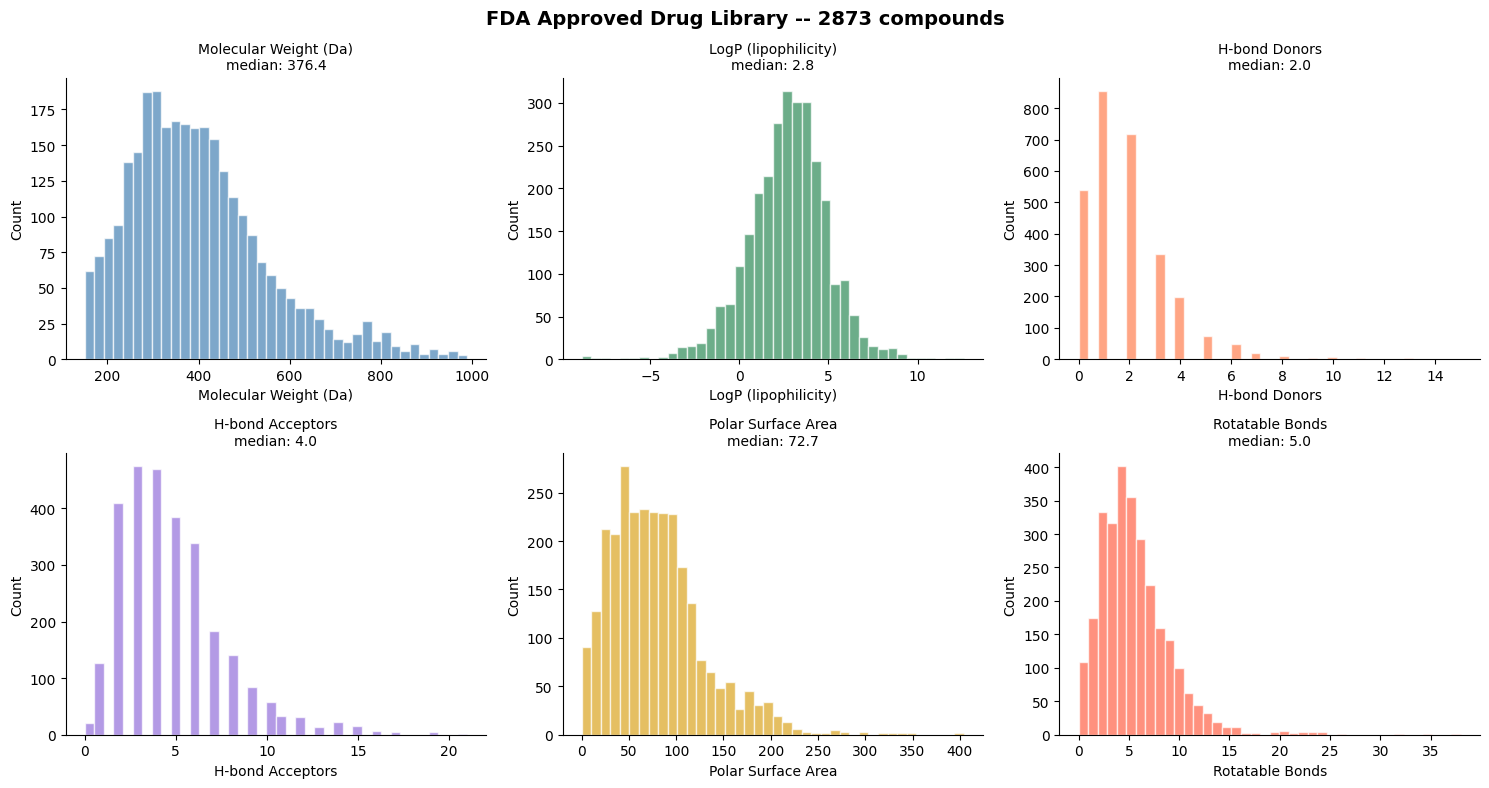

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'FDA Approved Drug Library -- {len(df_clean)} compounds', fontsize=14, fontweight='bold')

plot_configs = [
    ('molecular_weight', 'Molecular Weight (Da)', 'steelblue'),
    ('alogp', 'LogP (lipophilicity)', 'seagreen'),
    ('hbd', 'H-bond Donors', 'coral'),
    ('hba', 'H-bond Acceptors', 'mediumpurple'),
    ('psa', 'Polar Surface Area', 'goldenrod'),
    ('rotatable_bonds', 'Rotatable Bonds', 'tomato')
]

for ax, (col, label, color) in zip(axes.flat, plot_configs):
    data = df_clean[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{label}\nmedian: {data.median():.1f}', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save the figure
fig_path = Path(output_dir_widget.value) / 'library_statistics.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figure saved: {fig_path}')
plt.show()

### Cell 10 -- Save the final library

Save as CSV (annotated, for analysis) and SMILES (for the ligand preparation pipeline).

In [12]:
def save_library(df, output_dir, filename):
    """
    Save the final drug library as CSV and SMILES files.
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Save annotated CSV
    csv_path = output_path / f'{filename}.csv'
    df.to_csv(csv_path, index=False)
    print(f'CSV saved: {csv_path}')
    print(f'  Rows: {len(df)}')
    print(f'  Columns: {list(df.columns)}')
    
    # Save SMILES file for docking pipeline
    # Format: SMILES identifier
    smi_path = output_path / f'{filename}.smi'
    with open(smi_path, 'w') as f:
        for _, row in df.iterrows():
            name = str(row['name']).replace(' ', '_').replace('/', '-')
            identifier = f"{row['chembl_id']}_{name}"
            f.write(f"{row['smiles']} {identifier}\n")
    print(f'SMILES file saved: {smi_path}')
    
    # Save a summary text file
    summary_path = output_path / f'{filename}_summary.txt'
    with open(summary_path, 'w') as f:
        f.write('BasementDrugDiscovery -- FDA Approved Drug Library\n')
        f.write('=' * 50 + '\n')
        f.write(f'Source: ChEMBL REST API (max_phase=4)\n')
        f.write(f'Total compounds: {len(df)}\n')
        f.write(f'MW range: {df["molecular_weight"].min():.1f} to {df["molecular_weight"].max():.1f} Da\n')
        f.write(f'Median MW: {df["molecular_weight"].median():.1f} Da\n')
        f.write(f'Median LogP: {df["alogp"].median():.2f}\n')
        f.write(f'PAINS filtered: Yes\n')
        f.write(f'Inorganic removed: Yes\n')
    print(f'Summary saved: {summary_path}')
    
    return csv_path, smi_path


csv_path, smi_path = save_library(
    df_clean,
    output_dir=output_dir_widget.value,
    filename=output_filename_widget.value
)

print('\nLibrary saved successfully.')
print(f'\nFinal summary:')
print(f'  Total FDA approved drugs: {len(df_clean)}')
print(f'  Ready for ligand preparation pipeline')

CSV saved: /home/sardism/BasementDrugDiscovery/data/fda_drugs/fda_approved_drugs.csv
  Rows: 2873
  Columns: ['chembl_id', 'name', 'smiles', 'inchi_key', 'molecular_weight', 'alogp', 'hbd', 'hba', 'psa', 'rotatable_bonds', 'heavy_atoms', 'max_phase']
SMILES file saved: /home/sardism/BasementDrugDiscovery/data/fda_drugs/fda_approved_drugs.smi
Summary saved: /home/sardism/BasementDrugDiscovery/data/fda_drugs/fda_approved_drugs_summary.txt

Library saved successfully.

Final summary:
  Total FDA approved drugs: 2873
  Ready for ligand preparation pipeline


### Cell 11 -- Preview the library

Show the first 10 compounds and draw a random sample of structures.

In [13]:
# Show first 10 rows
print(f'First 10 compounds in the library:\n')
display(df_clean[['chembl_id', 'name', 'molecular_weight', 'alogp', 'hbd', 'hba']].head(10))

First 10 compounds in the library:



,chembl_id,name,molecular_weight,alogp,hbd,hba
0,CHEMBL2,PRAZOSIN,383.41,1.78,1.0,8.0
1,CHEMBL3,NICOTINE,162.24,1.85,0.0,2.0
2,CHEMBL4,OFLOXACIN,361.37,1.54,1.0,6.0
3,CHEMBL5,NALIDIXIC ACID,232.24,1.42,1.0,4.0
4,CHEMBL6,INDOMETHACIN,357.79,3.93,1.0,4.0
5,CHEMBL403,SULBACTAM,233.24,-0.79,1.0,4.0
6,CHEMBL404,TAZOBACTAM,300.30,-1.52,1.0,7.0
7,CHEMBL8,CIPROFLOXACIN,331.35,1.58,2.0,5.0
8,CHEMBL9,NORFLOXACIN,319.34,1.27,2.0,5.0
9,CHEMBL6622,ISOSORBIDE DINITRATE,236.14,-1.06,0.0,8.0


Structure grid saved: /home/sardism/BasementDrugDiscovery/data/fda_drugs/sample_structures.png


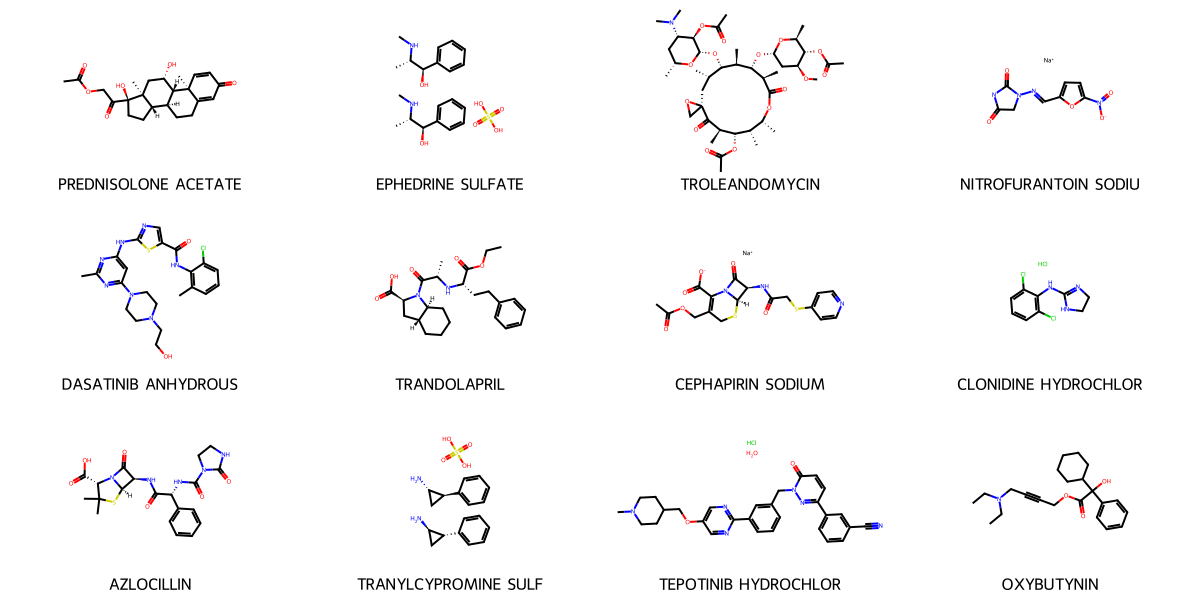

In [15]:
# Draw a random sample of 12 structures
sample = df_clean.sample(12, random_state=42)
mols = []
legends = []

for _, row in sample.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        mols.append(mol)
        name = str(row['name'])[:20] if row['name'] else row['chembl_id']
        legends.append(name)

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 200),
    legends=legends,
    returnPNG=False
)

# Save the structure grid
img_path = Path(output_dir_widget.value) / 'sample_structures.png'

# Save as PNG
from PIL import Image
import io

if hasattr(img, 'save'):
    img.save(str(img_path))
else:
    # Convert to PIL and save
    png_data = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(300, 200),
        legends=legends,
        returnPNG=True
    )
    with open(img_path, 'wb') as f:
        f.write(png_data)

print(f'Structure grid saved: {img_path}')

# Display in notebook
from IPython.display import Image as IPImage
display(IPImage(filename=str(img_path)))

---
## What comes next

The library is downloaded and ready. The next notebook prepares the 3D structures for docking.

**Notebook 02** will take each SMILES string, generate a 3D conformation using RDKit, add hydrogens, and convert to PDBQT format using Meeko. That file format is what AutoDock Vina reads.

**GitHub:** https://github.com/sardism/BasementDrugDiscovery